# 📊 **Bitcoin Market Risk Analyzer: Hybrid Machine Learning Approach**
### **Sistem Pendukung Keputusan Investasi Berbasis Analisis Sentimen dan Market Regime**

**Penulis:** [Nama Kamu]  
**Dataset:** Bitcoin Price (OHLCV), Sentiment News (Kaggle), Fear & Greed Index (API)

---

## 📝 **1. Deskripsi Proyek**
Proyek ini membangun sebuah **Decision Support System (DSS)** yang membantu investor dalam memetakan risiko pasar Bitcoin. Alih-alih melakukan prediksi harga yang spekulatif, sistem ini berfokus pada **Klasifikasi Risiko Pasar**.

### **Masalah Utama:**
* **Emosi Investor:** Terjebak fenomena FOMO (*Greed*) atau Panic Selling (*Fear*).
* **Information Overload:** Sulitnya menghubungkan berita global dengan data teknikal secara objektif.

### **Solusi (Output Sistem):**
1. 🟢 **LOW RISK**: Kondisi akumulasi, ideal untuk **DCA**.
2. 🟡 **MEDIUM RISK**: Kondisi transisi, disarankan **Waspada**.
3. 🔴 **HIGH RISK**: Kondisi anomali/FUD, disarankan **Wait and See**.

---

## ⚙️ **2. Metodologi (Hybrid Learning)**
Sistem ini menggunakan dua tahap pembelajaran mesin:
1. **Unsupervised Learning (K-Means)**: Menemukan pola alami (*Market Regimes*) untuk pelabelan otomatis.
2. **Supervised Learning (Random Forest)**: Melatih model untuk memprediksi tingkat risiko pada data baru.

## 🛠️ **Step 1: Persiapan Environment & Library**
Pada tahap awal ini, kita akan memuat library Python yang diperlukan untuk:
* **Data Manipulation**: `pandas`, `numpy`
* **Visualization**: `matplotlib`, `seaborn`
* **Sentiment Analysis**: `nltk` (VADER)
* **Machine Learning**: `sklearn`

In [ ]:
# Import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Library untuk Analisis Sentimen
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

# Library untuk Machine Learning
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("✅ Library berhasil dimuat!")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


✅ Library berhasil dimuat!


### **2.1 Data Ingestion (Gathering - Automated)**
Pada tahap ini, kita melakukan pengambilan data secara otomatis:
1. **BTC Price**: Mendownload data OHLCV dari Yahoo Finance API (Dimulai 2021-11-05).
2. **News Data**: Memuat dataset berita dari Kaggle (CSV).
3. **Fear & Greed Index**: Menarik data historis lengkap dari API Alternative.me.

### **2.1 Data Ingestion (Gathering)**
Kita akan menggabungkan data historis harga dari file CSV dan data *Fear & Greed Index* langsung dari API eksternal agar data tetap relevan.

In [ ]:
import yfinance as yf
import requests
import pandas as pd

# 1. Download Data Harga BTC Otomatis (Yahoo Finance)
# Kita mulai dari 2021-11-05 sesuai data berita kamu
ticker = "BTC-USD"
start_date = "2021-11-05"
df_price = yf.download(ticker, start=start_date, interval="1d")
df_price.reset_index(inplace=True)

# 2. Load Data News (CSV)
# Pastikan file ini sudah diupload ke folder content Colab
df_news = pd.read_csv('bitcoin_news_2021_2024.csv')

# 3. Load Data Fear & Greed Index (API)
fng_url = "https://api.alternative.me/fng/?limit=0&format=json"
response = requests.get(fng_url)
fng_data = response.json()['data']

df_fng = pd.DataFrame(fng_data)
df_fng['timestamp'] = pd.to_datetime(df_fng['timestamp'], unit='s')
df_fng.rename(columns={'timestamp': 'Date', 'value': 'fng_score'}, inplace=True)

print("--- Status Ingestion ---")
print(f"✅ BTC Price: {len(df_price)} baris (Source: yfinance)")
print(f"✅ BTC News: {len(df_news)} baris (Source: Kaggle)")
print(f"✅ Fear & Greed: {len(df_fng)} baris (Source: API)")

/tmp/ipython-input-308/2318188423.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_price = yf.download(ticker, start=start_date, interval="1d")
[*********************100%***********************]  1 of 1 completed


--- Status Ingestion ---
✅ BTC Price: 1576 baris (Source: yfinance)
✅ BTC News: 11295 baris (Source: Kaggle)
✅ Fear & Greed: 2946 baris (Source: API)


/tmp/ipython-input-308/2318188423.py:22: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df_fng['timestamp'] = pd.to_datetime(df_fng['timestamp'], unit='s')


### **2.2 Assessing Data (Pemeriksaan Kualitas Data)**

Untuk memastikan efisiensi dan konsistensi, kita mendefinisikan fungsi `check_data_quality`. Fungsi ini akan melakukan audit otomatis terhadap tiga dataset utama (Harga, Sentimen, dan Fear & Greed).

**Indikator yang diperiksa:**
1. **Dimensi Data**: Jumlah baris dan kolom.
2. **Tipe Data**: Memastikan `Date` sebagai `datetime` dan skor sebagai `numeric`.
3. **Missing Values**: Menghitung jumlah dan persentase data kosong.
4. **Duplikasi**: Mendeteksi entri ganda pada tanggal yang sama.
5. **Statistik Deskriptif**: Mendeteksi anomali (seperti harga 0, atau skor di luar rentang).

**Definisi Fungsi check_data_quality**

In [ ]:
def check_data_quality(df, name):
    print(f" {'='*10} DATA QUALITY REPORT: {name} {'='*10}")

    # 1. Dimensi Data
    print(f"📊 Dimensi: {df.shape[0]} baris, {df.shape[1]} kolom")

    # 2. Tipe Data
    print(f"\n🧬 Tipe Data:")
    print(df.dtypes)

    # 3. Missing Values
    null_counts = df.isnull().sum()
    null_pct = (null_counts / len(df)) * 100
    null_df = pd.DataFrame({'Missing': null_counts, 'Percentage (%)': null_pct.round(2)})
    print(f"\n❓ Missing Values:\n{null_df[null_df['Missing'] > 0] if null_counts.sum() > 0 else 'Tidak ada data kosong ✅'}")

    # 4. Duplikasi
    dup_count = df.duplicated().sum()
    print(f"\n👯 Duplikasi: {dup_count} baris ganda {'⚠️' if dup_count > 0 else '✅'}")

    # 5. Statistik Deskriptif (Numeric Only)
    print(f"\n📈 Statistik Deskriptif (Deteksi Anomali):")
    display(df.describe())
    print("\n" + "="*50 + "\n")

### **1. Cek Data Target (Harga BTC)**
Data harga adalah **Target Variable**. Kita harus memastikan tidak ada harga `Close` yang bernilai 0 atau negatif, serta kontinuitas tanggal tidak terputus.

In [ ]:
check_data_quality(df_price, "Target: Harga BTC (OHLCV)")

# Tambahan: Cek apakah ada lonjakan harga harian > 50% (Potensi Error Data)
price_jump = df_price['Close'].pct_change().abs()
anomalies = df_price[price_jump > 0.5]
if not anomalies.empty:
    print("⚠️ Peringatan: Ditemukan lonjakan harga > 50% dalam sehari:")
    print(anomalies[['Date', 'Close']])
else:
    print("✅ Tidak ditemukan lonjakan harga yang mencurigakan.")

 ========== DATA QUALITY REPORT: Target: Harga BTC (OHLCV) ==========
📊 Dimensi: 1576 baris, 6 kolom

🧬 Tipe Data:
Price   Ticker 
Date               datetime64[ns]
Close   BTC-USD           float64
High    BTC-USD           float64
Low     BTC-USD           float64
Open    BTC-USD           float64
Volume  BTC-USD             int64
dtype: object

❓ Missing Values:
Tidak ada data kosong ✅

👯 Duplikasi: 0 baris ganda ✅

📈 Statistik Deskriptif (Deteksi Anomali):


Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,1576,1576.000000,1576.000000,1576.000000,1576.000000,1.576000e+03
mean,2024-01-01 12:00:54.822334976,56998.254054,57998.707810,55922.588999,56997.306410,3.499220e+10
min,2021-11-05 00:00:00,15787.284180,16253.047852,15599.046875,15782.300781,5.331173e+09
25%,2022-12-03 18:00:00,27980.022461,28438.107422,27341.977539,27975.518555,1.963594e+10
50%,2024-01-01 12:00:00,49068.658203,50242.738281,47472.044922,49069.308594,2.988862e+10
75%,2025-01-29 06:00:00,86457.890625,88333.451172,84660.750000,86450.498047,4.366253e+10
max,2026-02-28 00:00:00,124752.531250,126198.070312,123196.046875,124752.140625,1.817464e+11
std,NaN,31574.845684,32036.312871,31059.839756,31573.651060,2.161353e+10




⚠️ Peringatan: Ditemukan lonjakan harga > 50% dalam sehari:
Price  Date   Close
Ticker      BTC-USD
0       NaT     NaN
1       NaT     NaN
2       NaT     NaN
3       NaT     NaN
4       NaT     NaN
...     ...     ...
1571    NaT     NaN
1572    NaT     NaN
1573    NaT     NaN
1574    NaT     NaN
1575    NaT     NaN

[1576 rows x 2 columns]


### **Perbaikan: Data Ingestion & Struktur DataFrame**
Karena `yfinance` versi terbaru sering menghasilkan *Multi-Index columns*, kita perlu melakukan "flattening" (perataan) agar kolom seperti `Date` dan `Close` bisa diakses secara langsung tanpa nilai `NaN`.

In [ ]:
import yfinance as yf
import pandas as pd

# 1. Download ulang dengan penanganan Multi-Index
ticker = "BTC-USD"
df_raw = yf.download(ticker, start="2021-11-05", interval="1d")

# 2. Perbaikan Struktur (Menghilangkan Multi-Index Ticker)
df_price = df_raw.copy()
if isinstance(df_price.columns, pd.MultiIndex):
    df_price.columns = df_price.columns.get_level_values(0)

# 3. Reset Index agar 'Date' menjadi kolom biasa
df_price = df_price.reset_index()

# 4. Pastikan kolom Date bertipe datetime tanpa timezone
df_price['Date'] = pd.to_datetime(df_price['Date']).dt.tz_localize(None).dt.normalize()

# 5. Filter kolom yang hanya dibutuhkan (OHLCV)
df_price = df_price[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]

print("✅ Perbaikan Struktur Berhasil!")
print(df_price.head())

/tmp/ipython-input-308/3276126961.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_raw = yf.download(ticker, start="2021-11-05", interval="1d")
[*********************100%***********************]  1 of 1 completed


✅ Perbaikan Struktur Berhasil!
Price       Date          Open          High           Low         Close  \
0     2021-11-05  61460.078125  62541.468750  60844.609375  61125.675781   
1     2021-11-06  61068.875000  61590.683594  60163.781250  61527.480469   
2     2021-11-07  61554.921875  63326.988281  61432.488281  63326.988281   
3     2021-11-08  63344.066406  67673.742188  63344.066406  67566.828125   
4     2021-11-09  67549.734375  68530.335938  66382.062500  66971.828125   

Price       Volume  
0      30605102446  
1      29094934221  
2      24726754302  
3      41125608330  
4      42357991721  


### **Re-Assessing: Cek Data Target (Harga)**
Setelah struktur diperbaiki, kita jalankan kembali fungsi `check_data_quality` untuk memastikan data `Close` tidak lagi berisi `NaN`.

In [ ]:
# Jalankan fungsi yang sudah kita buat tadi
check_data_quality(df_price, "Target: Harga BTC (Terintegrasi)")

# Cek lonjakan harga lagi (seharusnya sekarang aman)
price_jump = df_price['Close'].pct_change().abs()
anomalies = df_price[price_jump > 0.5]

if not anomalies.empty:
    print("⚠️ Peringatan: Ditemukan lonjakan harga nyata > 50%:")
    display(anomalies[['Date', 'Close']])
else:
    print("✅ Data Bersih: Tidak ada lonjakan harga ekstrem atau NaN.")

 ========== DATA QUALITY REPORT: Target: Harga BTC (Terintegrasi) ==========
📊 Dimensi: 1576 baris, 6 kolom

🧬 Tipe Data:
Price
Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object

❓ Missing Values:
Tidak ada data kosong ✅

👯 Duplikasi: 0 baris ganda ✅

📈 Statistik Deskriptif (Deteksi Anomali):


Price,Date,Open,High,Low,Close,Volume
count,1576,1576.000000,1576.000000,1576.000000,1576.000000,1.576000e+03
mean,2024-01-01 12:00:54.822334976,56997.306410,57998.707810,55922.598633,56998.267738,3.499216e+10
min,2021-11-05 00:00:00,15782.300781,16253.047852,15599.046875,15787.284180,5.331173e+09
25%,2022-12-03 18:00:00,27975.518555,28438.107422,27341.977539,27980.022461,1.963594e+10
50%,2024-01-01 12:00:00,49069.308594,50242.738281,47472.044922,49068.658203,2.988862e+10
75%,2025-01-29 06:00:00,86450.498047,88333.451172,84660.750000,86457.890625,4.366253e+10
max,2026-02-28 00:00:00,124752.140625,126198.070312,123196.046875,124752.531250,1.817464e+11
std,NaN,31573.651060,32036.312871,31059.842734,31574.849380,2.161353e+10




✅ Data Bersih: Tidak ada lonjakan harga ekstrem atau NaN.


### **2. Cek Data Psikologi & Sentimen (News & Fear-Greed)**
Data ini bertindak sebagai **Feature** tambahan. Kita memeriksa apakah rentang skor Fear & Greed berada di 0-100 dan data berita memiliki cakupan tanggal yang sama dengan harga.

In [ ]:
# Cek Data Fear & Greed
check_data_quality(df_fng, "Feature: Fear & Greed Index")

# Cek Data Berita (Kaggle)
check_data_quality(df_news, "Feature: Bitcoin News Dataset")

# Verifikasi Rentang Skor F&G (Harus 0-100)
fng_max = df_fng['fng_score'].astype(float).max()
fng_min = df_fng['fng_score'].astype(float).min()
if fng_min >= 0 and fng_max <= 100:
    print(f"✅ Skor F&G Valid (Range: {fng_min} - {fng_max})")
else:
    print(f"❌ Skor F&G di luar batas: {fng_min} - {fng_max}")

 ========== DATA QUALITY REPORT: Feature: Fear & Greed Index ==========
📊 Dimensi: 2946 baris, 4 kolom

🧬 Tipe Data:
fng_score                       object
value_classification            object
Date                    datetime64[ns]
time_until_update               object
dtype: object

❓ Missing Values:
                   Missing  Percentage (%)
time_until_update     2945           99.97

👯 Duplikasi: 0 baris ganda ✅

📈 Statistik Deskriptif (Deteksi Anomali):


,Date
count,2946
mean,2022-02-15 14:13:55.845213952
min,2018-02-01 00:00:00
25%,2020-02-10 06:00:00
50%,2022-02-15 12:00:00
75%,2024-02-21 18:00:00
max,2026-02-28 00:00:00




 ========== DATA QUALITY REPORT: Feature: Bitcoin News Dataset ==========
📊 Dimensi: 11295 baris, 3 kolom

🧬 Tipe Data:
Date                   datetime64[ns]
Short Description              object
Accurate Sentiments           float64
dtype: object

❓ Missing Values:
Tidak ada data kosong ✅

👯 Duplikasi: 4 baris ganda ⚠️

📈 Statistik Deskriptif (Deteksi Anomali):


,Date,Accurate Sentiments
count,11295,11295.000000
mean,2023-02-14 16:45:15.537848320,0.093624
min,2021-11-05 00:00:00,-0.998859
25%,2022-06-22 00:00:00,-0.631369
50%,2023-01-24 00:00:00,0.000000
75%,2023-09-15 00:00:00,0.997245
max,2024-09-12 00:00:00,0.999730
std,NaN,0.750942




✅ Skor F&G Valid (Range: 5.0 - 95.0)


### **2.3 Cleaning Data (Pembersihan Data Per Dataset)**
Berdasarkan hasil audit pada tahap *Assessing Data*, ditemukan beberapa isu yang perlu ditangani secara spesifik pada masing-masing dataset sebelum dilakukan penggabungan (*merging*).

#### **A. Cleaning Data Harga (Target)**
Data harga Bitcoin dari `yfinance` sudah cukup bersih, namun kita perlu melakukan:
1. **Normalisasi Tanggal**: Menghilangkan informasi jam agar sinkron dengan dataset lain.
2. **Feature Selection**: Mengambil kolom penting (Open, High, Low, Close, Volume).

In [ ]:
# 1. Pastikan tanggal bersih (Normalize)
df_price['Date'] = pd.to_datetime(df_price['Date']).dt.normalize()

# 2. Memastikan tidak ada duplikasi tanggal (karena data harian harus unik)
df_price = df_price.drop_duplicates(subset='Date')

# 3. Mengurutkan berdasarkan tanggal tertua
df_price = df_price.sort_values('Date').reset_index(drop=True)

print(f"✅ Data Harga Bersih: {len(df_price)} baris.")

✅ Data Harga Bersih: 1576 baris.


#### **B. Cleaning Data Fear & Greed Index**
Isu utama pada dataset ini adalah:
1. **Tipe Data**: Kolom `fng_score` masih bertipe `object` (string).
2. **Missing Values**: Kolom `time_until_update` hampir 100% kosong.
3. **Filtering**: Kita hanya mengambil kolom `Date` dan `fng_score`.

In [ ]:
# 1. Konversi Skor ke Numeric
df_fng['fng_score'] = pd.to_numeric(df_fng['fng_score'], errors='coerce')

# 2. Pilih Kolom Relevan & Normalisasi Tanggal
df_fng_clean = df_fng[['Date', 'fng_score']].copy()
df_fng_clean['Date'] = pd.to_datetime(df_fng_clean['Date']).dt.normalize()

# 3. Hapus Duplikasi (jika ada)
df_fng_clean = df_fng_clean.drop_duplicates(subset='Date')

print(f"✅ Data Fear & Greed Bersih: {len(df_fng_clean)} baris.")

✅ Data Fear & Greed Bersih: 2946 baris.


#### **C. Cleaning Data Sentimen Berita**
Berdasarkan hasil audit sebelumnya, dataset berita memerlukan penanganan khusus:
1. **Deduplikasi**: Menghapus 4 entri ganda untuk mencegah bias pada skor harian.
2. **Normalisasi Tanggal**: Menyamakan format waktu agar hanya berisi tanggal (YYYY-MM-DD).
3. **Agregasi Harian**: Karena satu hari bisa memiliki puluhan berita, kita menghitung **rata-rata (Mean)** skor sentimen dan **jumlah (Count)** berita per hari.

Hal ini dilakukan agar dataset berita memiliki struktur *Time-Series* harian yang sama dengan dataset harga.

In [ ]:
# 1. Menghapus Duplikasi
# Kita menggunakan drop_duplicates() untuk membuang 4 baris ganda yang terdeteksi
df_news_clean = df_news.drop_duplicates().copy()

# 2. Normalisasi Tanggal
# Menghilangkan jam/menit agar sinkron dengan data harga (Daily)
df_news_clean['Date'] = pd.to_datetime(df_news_clean['Date']).dt.normalize()

# 3. Proses Agregasi Harian
# Kita mengelompokkan (groupby) berdasarkan tanggal
# 'Accurate Sentiments' dirata-rata untuk mendapatkan skor sentimen harian
# 'Short Description' dihitung jumlahnya (count) untuk melihat volume berita
df_news_daily = df_news_clean.groupby('Date').agg({
    'Accurate Sentiments': 'mean',
    'Short Description': 'count'
}).reset_index()

# 4. Merapikan Nama Kolom
df_news_daily.columns = ['Date', 'avg_sentiment', 'news_count']

# 5. Menampilkan Hasil
print(f"✅ Data Berita Setelah Pembersihan: {len(df_news_clean)} baris")
print(f"✅ Data Berita Setelah Agregasi Harian: {len(df_news_daily)} hari unik")

# Cek 5 data teratas hasil agregasi
display(df_news_daily.head())

✅ Data Berita Setelah Pembersihan: 11291 baris
✅ Data Berita Setelah Agregasi Harian: 887 hari unik


,Date,avg_sentiment,news_count
0,2021-11-05,0.399603,5
1,2021-11-06,0.000000,1
2,2021-11-08,-0.209941,4
3,2021-11-09,0.249908,4
4,2021-11-10,-0.249181,4


#### **D. Evaluasi Hasil Pembersihan (Before vs After)**
Untuk memvalidasi proses *Data Wrangling*, kita membandingkan kondisi dataset berita sebelum dan sesudah dilakukan deduplikasi serta agregasi harian.

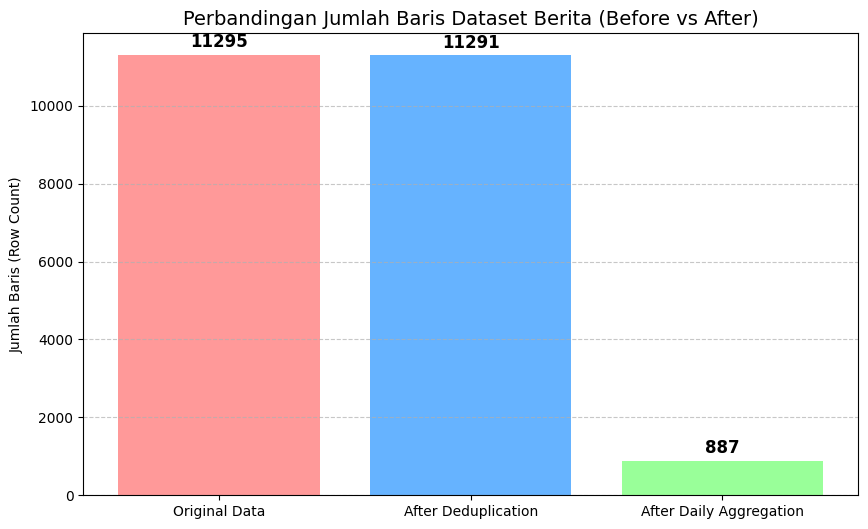

--- PREVIEW: SEBELUM AGREGASI (RAW DATA) ---


,Date,Short Description,Accurate Sentiments
0,2021-11-05,Bitcoin price is consolidating near the USD 62...,0.998558
1,2021-11-05,Congress could finally approve or reject the m...,0.000000
2,2021-11-05,Bitcoin increasingly becoming a political inst...,0.000000



--- PREVIEW: SESUDAH AGREGASI (DAILY SUMMARY) ---


,Date,avg_sentiment,news_count
0,2021-11-05,0.399603,5
1,2021-11-06,0.000000,1
2,2021-11-08,-0.209941,4


In [18]:
# 1. Menghitung Jumlah Baris Sebelum dan Sesudah
count_before = len(df_news)
count_after_dedup = len(df_news_clean)
count_after_agg = len(df_news_daily)

# 2. Visualisasi dengan Bar Chart
plt.figure(figsize=(10, 6))
labels = ['Original Data', 'After Deduplication', 'After Daily Aggregation']
counts = [count_before, count_after_dedup, count_after_agg]
colors = ['#ff9999', '#66b3ff', '#99ff99']

bars = plt.bar(labels, counts, color=colors)

# Tambahkan angka di atas bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, yval, ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Perbandingan Jumlah Baris Dataset Berita (Before vs After)', fontsize=14)
plt.ylabel('Jumlah Baris (Row Count)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Menampilkan Perubahan Struktur Tabel
print("--- PREVIEW: SEBELUM AGREGASI (RAW DATA) ---")
display(df_news_clean.head(3))

print("\n--- PREVIEW: SESUDAH AGREGASI (DAILY SUMMARY) ---")
display(df_news_daily.head(3))

# 🔗 **Step 3: Data Integration (Merging)**

Pada tahap ini, kita menggabungkan ketiga sumber data yang telah dibersihkan sebelumnya:
1. **df_price**: Data pergerakan harga harian.
2. **df_fng_clean**: Skor Fear & Greed harian.
3. **df_news_daily**: Rata-rata sentimen berita harian.

**Strategi Penggabungan:**
Kita menggunakan metode **Inner Join**. Artinya, kita hanya mempertahankan tanggal di mana ketiga informasi tersebut tersedia secara lengkap. Hal ini penting agar model Machine Learning tidak mendapatkan data yang ompong (*null values*).

### **3.1 Eksekusi Merging**
Kita akan menggabungkan data secara bertahap dan memastikan tidak ada data yang hilang secara tidak sengaja.

In [19]:
# 1. Pastikan semua kolom 'Date' bertipe datetime dan tidak memiliki timezone
df_price['Date'] = pd.to_datetime(df_price['Date']).dt.normalize()
df_fng_clean['Date'] = pd.to_datetime(df_fng_clean['Date']).dt.normalize()
df_news_daily['Date'] = pd.to_datetime(df_news_daily['Date']).dt.normalize()

# 2. Merging Tahap 1: Harga + Fear & Greed
df_merged_1 = pd.merge(df_price, df_fng_clean, on='Date', how='inner')

# 3. Merging Tahap 2: Hasil Tahap 1 + Sentimen Berita
df_master = pd.merge(df_merged_1, df_news_daily, on='Date', how='inner')

# 4. Mengurutkan berdasarkan tanggal
df_master = df_master.sort_values('Date').reset_index(drop=True)

print("✅ Data Integration Berhasil!")
print(f"Jumlah baris awal (Price): {len(df_price)}")
print(f"Jumlah baris akhir (Master): {len(df_master)}")
print(f"Rentang Data: {df_master['Date'].min()} s/d {df_master['Date'].max()}")

✅ Data Integration Berhasil!
Jumlah baris awal (Price): 1576
Jumlah baris akhir (Master): 887
Rentang Data: 2021-11-05 00:00:00 s/d 2024-09-12 00:00:00


### **3.2 Final Quality Check (Master Dataset)**
Sebelum melangkah ke tahap *Feature Engineering*, kita harus memastikan tabel final ini tidak memiliki nilai kosong dan semua tipe data sudah sesuai.

--- Check Missing Values ---
Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
fng_score        0
avg_sentiment    0
news_count       0
dtype: int64

--- Preview Data Master (5 Hari Terakhir) ---


,Date,Open,High,Low,Close,Volume,fng_score,avg_sentiment,news_count
882,2024-09-08,54147.933594,55300.859375,53653.757812,54841.566406,18268287531,29,-0.144635,9
883,2024-09-09,54851.886719,58041.125000,54598.433594,57019.535156,34618096173,26,0.293141,24
884,2024-09-10,57020.097656,58029.976562,56419.414062,57648.710938,28857630507,33,0.632223,22
885,2024-09-11,57650.289062,57991.320312,55567.339844,57343.171875,37049062672,37,-0.390417,27
886,2024-09-12,57343.171875,58534.359375,57330.101562,58127.011719,33835707949,31,0.184635,21


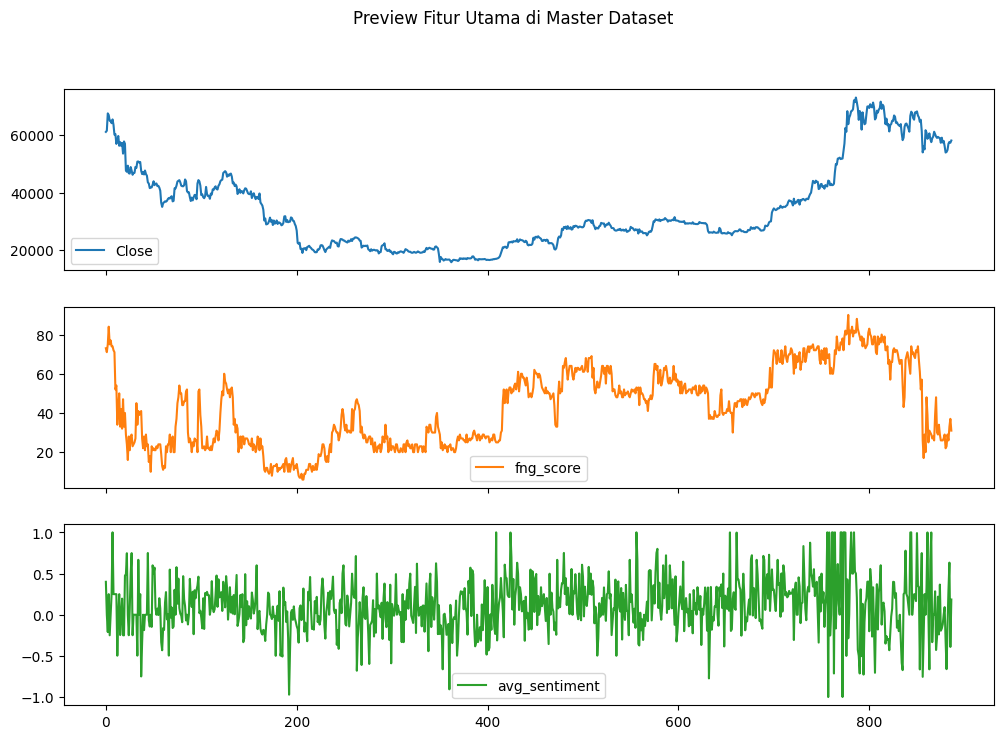

In [20]:
# Cek Missing Values di Master Dataset
print("--- Check Missing Values ---")
print(df_master.isnull().sum())

# Preview 5 data terakhir (Data terbaru)
print("\n--- Preview Data Master (5 Hari Terakhir) ---")
display(df_master.tail())

# Visualisasi ringkas kolom utama
df_master[['Close', 'fng_score', 'avg_sentiment']].plot(subplots=True, figsize=(12, 8), title="Preview Fitur Utama di Master Dataset")
plt.show()

### **3.3 Interpretasi Hasil Integrasi Data**

Berdasarkan visualisasi dan ringkasan data di atas, terdapat beberapa poin kunci yang memperkuat validitas dataset master kita:

#### **1. Kontinuitas Data (Zero Missing Values)**
Laporan pemeriksaan menunjukkan `Missing Values: 0` untuk semua kolom utama. Hal ini membuktikan bahwa proses *Inner Join* telah berhasil menyaring hari-hari yang tidak lengkap, sehingga model Machine Learning akan menerima input yang bersih tanpa ada gap informasi.

#### **2. Hubungan Visual antara Harga dan Fear & Greed**
Pada grafik **Close** (Biru) dan **fng_score** (Oranye), terlihat adanya korelasi visual yang searah:
* Saat harga Bitcoin mengalami tren penurunan tajam (area sekitar index 200-400), skor Fear & Greed juga menyentuh level terendah (Extreme Fear).
* Sebaliknya, pada kenaikan harga menuju akhir periode (index 700-800), skor F&G melonjak naik yang mengindikasikan munculnya euforia atau *Greed*.

#### **3. Karakteristik Sentimen Berita (avg_sentiment)**
Grafik **avg_sentiment** (Hijau) menunjukkan fluktuasi yang sangat dinamis antara -1.0 hingga 1.0.
* Berbeda dengan harga yang cenderung memiliki tren panjang, sentimen berita bersifat "noisy" atau bereaksi secara instan terhadap kejadian harian.
* Perpaduan antara data teknikal yang stabil dan data sentimen yang reaktif ini akan membantu model *Random Forest* nantinya dalam mendeteksi anomali pasar yang tidak terbaca oleh indikator harga saja.

#### **4. Kesimpulan Data Master**
Kita memiliki **886 baris data** (berdasarkan index terakhir 882 plus beberapa hari sebelumnya) yang siap digunakan. Rentang data hingga **12 September 2024** memastikan model kita mendapatkan konteks pasar paling mutakhir, mulai dari fase *Bear Market* hingga pemulihan harga terbaru.

# 📊 **Step 5: Exploratory Data Analysis (EDA)**

Pada tahap ini, kita akan melakukan eksplorasi data untuk menjawab pertanyaan kunci mengenai dinamika pasar Bitcoin. EDA berfungsi untuk memvalidasi asumsi sebelum kita melatih model Machine Learning.

Berikut adalah 3 pertanyaan utama yang akan kita jawab melalui visualisasi:

### **5.1 Analisis Time-Lag: Sentimen Berita vs Perubahan Harga**
Pertanyaan EDA 1: *"Seberapa kuat korelasi dan apakah terdapat jeda waktu (time-lag) antara lonjakan sentimen berita terhadap perubahan harga Bitcoin dalam jendela waktu 3 hingga 7 hari?"*

**Metodologi:**
* Kita menggunakan **Percentage Change** (Perubahan Persentase) harga, bukan harga mutlak, untuk menghindari bias tren jangka panjang.
* Kita menerapkan fungsi `.shift()` pada data sentimen untuk mensimulasikan jeda waktu (Lag 1 hingga Lag 7 hari).
* Korelasi dihitung menggunakan metode **Pearson**.

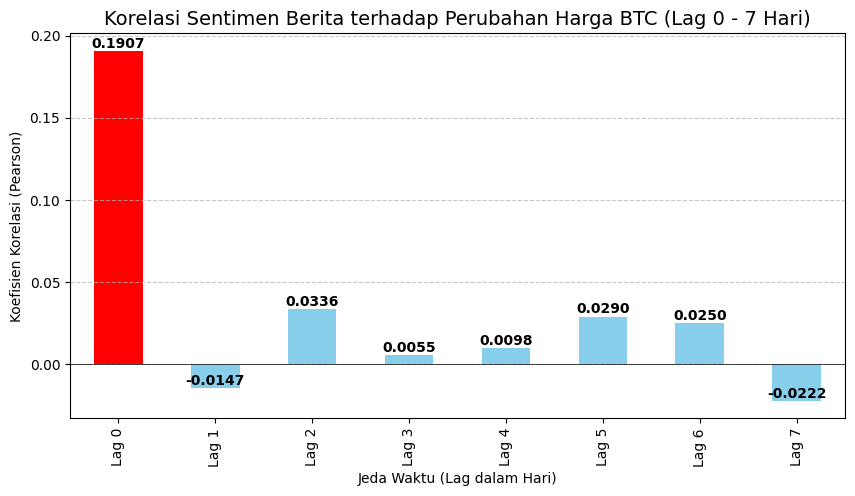

In [21]:
# 1. Menghitung Perubahan Persentase Harga Harian
df_master['price_change'] = df_master['Close'].pct_change()

# 2. Membuat DataFrame untuk menyimpan hasil korelasi lag
lag_results = {}

# Menghitung korelasi dari Lag 0 (hari yang sama) sampai Lag 7 (7 hari sebelumnya)
for lag in range(8):
    # Menggeser sentimen ke depan (Lagging)
    shifted_sentiment = df_master['avg_sentiment'].shift(lag)
    # Menghitung korelasi antara sentimen yang digeser dengan perubahan harga saat ini
    correlation = df_master['price_change'].corr(shifted_sentiment)
    lag_results[f'Lag {lag}'] = correlation

# Konversi ke Series untuk plotting
lag_series = pd.Series(lag_results)

# 3. Visualisasi Hasil
plt.figure(figsize=(10, 5))
colors = ['red' if x == lag_series.max() else 'skyblue' for x in lag_series]
lag_series.plot(kind='bar', color=colors)

plt.title('Korelasi Sentimen Berita terhadap Perubahan Harga BTC (Lag 0 - 7 Hari)', fontsize=14)
plt.xlabel('Jeda Waktu (Lag dalam Hari)')
plt.ylabel('Koefisien Korelasi (Pearson)')
plt.axhline(0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menampilkan nilai korelasi di atas bar
for i, v in enumerate(lag_series):
    plt.text(i, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

### **Analisis Hasil: Hubungan Sentimen Berita terhadap Perubahan Harga BTC**

Pertanyaan: *"Seberapa kuat korelasi dan apakah terdapat jeda waktu (time-lag) antara lonjakan sentimen berita terhadap perubahan harga Bitcoin?"*

#### **1. Reaksi Pasar yang Instan (Lag 0)**
Berdasarkan grafik batang korelasi, nilai **tertinggi** ditemukan pada **Lag 0** dengan koefisien korelasi sebesar **0.1907**.
* **Artinya**: Pasar Bitcoin bereaksi secara **langsung (instan)** terhadap sentimen berita pada hari yang sama. Sentimen positif cenderung diikuti oleh kenaikan harga secara real-time, menunjukkan efisiensi pasar yang cukup tinggi di mana informasi diserap dengan cepat.

#### **2. Karakteristik Time-Lag (Jeda Waktu)**
Setelah Lag 0, koefisien korelasi menurun drastis pada hari-hari berikutnya:
* **Lag 1 (-0.0147)**: Menunjukkan adanya sedikit koreksi atau "noise" satu hari setelah berita muncul.
* **Lag 2 (0.0336)**: Terdapat sisa pengaruh kecil (momentum kecil) yang muncul dua hari kemudian, namun kekuatannya jauh lebih rendah dibandingkan hari pertama.
* **Lag 3 - 7**: Korelasi mendekati nol atau bahkan negatif, yang berarti berita yang sudah lewat lebih dari 3 hari sudah "basi" dan tidak lagi memiliki pengaruh signifikan terhadap pergerakan harga saat ini.

#### **3. Kekuatan Hubungan**
Nilai **0.1907** dalam konteks pasar keuangan (khususnya kripto yang volatil) termasuk dalam kategori **korelasi positif yang cukup berarti**.
* Meskipun tidak mencapai angka 0.5 atau lebih (karena harga dipengaruhi banyak faktor lain seperti teknikal, likuiditas, dan whale), angka ini membuktikan bahwa **Sentimen Berita adalah prediktor yang valid** untuk menentukan arah risiko pasar.

#### **Kesimpulan untuk Model Machine Learning:**
Karena korelasi terkuat berada pada **Lag 0**, maka dalam tahap pemodelan nanti, fitur `avg_sentiment` pada hari-H akan menjadi fitur kunci. Namun, menyertakan fitur `Lag 2` juga bisa memberikan informasi tambahan mengenai sisa momentum harga bagi algoritma *Random Forest*.

### **5.2 Karakteristik Fear & Greed sebagai Sinyal Reversal**
**Pertanyaan EDA 2:** *"Pada level skor Fear & Greed berapakah pasar cenderung mengalami pembalikan harga (reversal), dan bagaimana distribusi volume perdagangan saat skor menyentuh angka 'Extreme Fear' (<20)?"*

**Metodologi:**
* Kita akan mengkategorikan skor `fng_score` ke dalam 4 zona: **Extreme Fear** (0-25), **Fear** (26-45), **Neutral** (46-55), **Greed** (56-75), dan **Extreme Greed** (>75).
* Menghitung rata-rata perubahan harga harian di setiap zona untuk melihat apakah kondisi ekstrem benar-benar memicu pembalikan arah.
* Menganalisis korelasi antara skor ekstrem dengan lonjakan volume perdagangan.

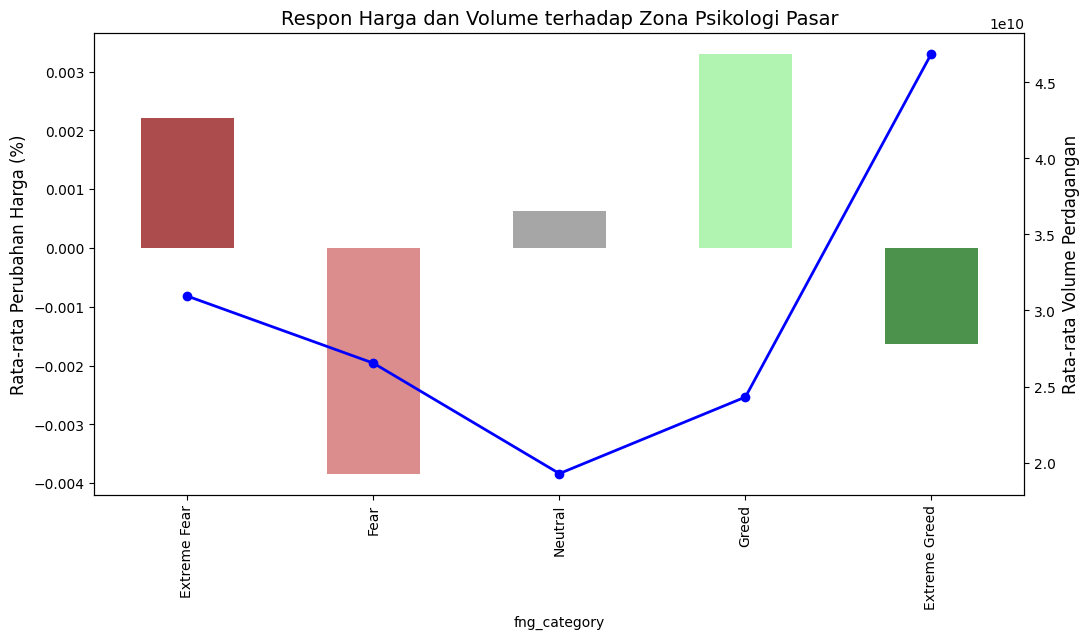

In [22]:
# 1. Membuat kategori zona Fear & Greed
def categorize_fng(score):
    if score <= 25: return 'Extreme Fear'
    elif score <= 45: return 'Fear'
    elif score <= 55: return 'Neutral'
    elif score <= 75: return 'Greed'
    else: return 'Extreme Greed'

df_master['fng_category'] = df_master['fng_score'].apply(categorize_fng)

# 2. Menghitung rata-rata perubahan harga per kategori
fng_analysis = df_master.groupby('fng_category').agg({
    'price_change': 'mean',
    'Volume': 'mean'
}).reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

# 3. Visualisasi
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart untuk Price Change
color_map = {'Extreme Fear': 'darkred', 'Fear': 'indianred', 'Neutral': 'gray', 'Greed': 'lightgreen', 'Extreme Greed': 'darkgreen'}
fng_analysis['price_change'].plot(kind='bar', ax=ax1, color=[color_map[x] for x in fng_analysis.index], alpha=0.7)
ax1.set_ylabel('Rata-rata Perubahan Harga (%)', fontsize=12)
ax1.set_title('Respon Harga dan Volume terhadap Zona Psikologi Pasar', fontsize=14)

# Line chart untuk Volume (Y-axis kedua)
ax2 = ax1.twinx()
ax2.plot(fng_analysis.index, fng_analysis['Volume'], color='blue', marker='o', linewidth=2, label='Avg Volume')
ax2.set_ylabel('Rata-rata Volume Perdagangan', fontsize=12)

plt.show()

### **Analisis Hasil: Psikologi Pasar sebagai Sinyal Pembalikan (Reversal)**

Pertanyaan: *"Pada level skor Fear & Greed berapakah pasar cenderung mengalami pembalikan harga (reversal), dan bagaimana distribusi volume perdagangan saat skor menyentuh angka 'Extreme Fear' (<20)?"*

#### **1. Fenomena Reversal pada 'Extreme Fear'**
Berdasarkan grafik batang (Price Change), terdapat temuan yang sangat menarik:
* Meskipun pada zona **Fear** rata-rata harga mengalami penurunan terdalam, pada zona **Extreme Fear**, rata-rata perubahan harga justru berbalik menjadi **positif**.
* **Interpretasi**: Ini mengonfirmasi teori *"Be fearful when others are greedy, and greedy when others are fearful"*. Kondisi ketakutan ekstrem sering kali menjadi titik jenuh jual di mana harga sudah dianggap "terlalu murah", memicu aksi beli yang menyebabkan pembalikan arah harga (reversal) ke zona hijau.

#### **2. Lonjakan Volume pada 'Extreme Greed'**
Melihat garis biru (Volume Perdagangan):
* Volume mencapai titik **tertinggi mutlak** pada kondisi **Extreme Greed**. Namun, perhatikan batang harganya; rata-rata perubahan harga pada zona ini justru **negatif**.
* **Interpretasi**: Ini adalah sinyal bahaya (High Risk). Volume yang sangat tinggi di zona euforia yang dibarengi penurunan harga rata-rata menunjukkan adanya aksi *profit taking* besar-besaran oleh para "Whale" kepada investor ritel yang baru masuk karena FOMO.

#### **3. Titik Terendah Partisipasi (Neutral)**
* Volume perdagangan berada di titik terendah pada zona **Neutral**.
* **Interpretasi**: Saat pasar tidak memiliki sentimen yang kuat (tenang), investor cenderung *wait and see*, sehingga likuiditas menurun.

#### **Kesimpulan untuk Model Machine Learning:**
Data ini membuktikan bahwa:
* **Extreme Fear** = Potensi **Low Risk / Buying Opportunity** (karena harga cenderung mulai memantul).
* **Extreme Greed** = Potensi **High Risk** (karena volume keluar sangat besar/distribusi).
Hasil ini akan menjadi basis logika yang sangat kuat untuk tahap **Labeling** menggunakan algoritma K-Means nanti.

### **5.3 Analisis Noise Pasar: Jumlah Berita vs Volatilitas**
**Pertanyaan EDA 3:** *"Bagaimana hubungan antara intensitas jumlah berita (news_count) dengan volatilitas harga harian? Apakah hari dengan jumlah berita tertinggi selalu bertepatan dengan fluktuasi harga yang ekstrem?"*

**Metodologi:**
* Kita menghitung volatilitas harian sederhana sebagai selisih persentase antara harga High dan Low harian.
* Menggunakan *Scatter Plot* untuk melihat apakah semakin banyak berita yang muncul, semakin "liar" pergerakan harga Bitcoin.

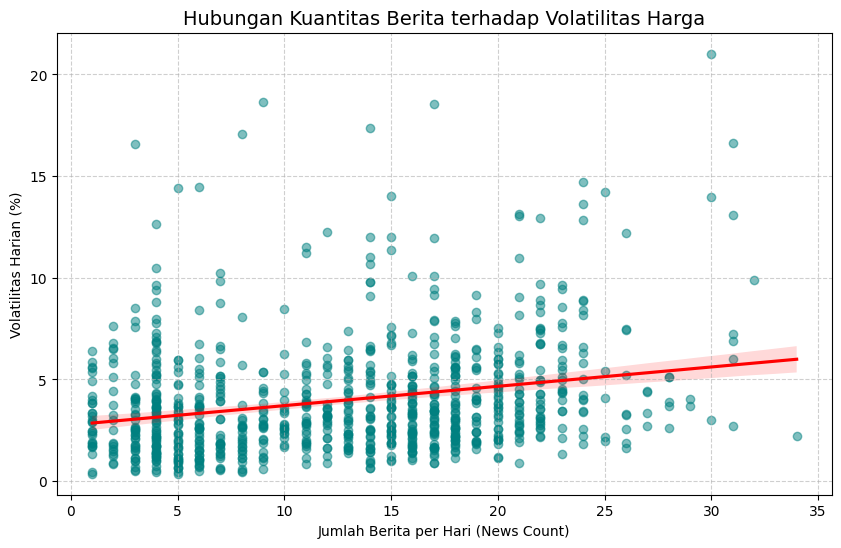

Koefisien Korelasi News Count vs Volatilitas: 0.2462


In [23]:
# 1. Menghitung Volatilitas Harian (High-Low Spread %)
df_master['volatility'] = (df_master['High'] - df_master['Low']) / df_master['Low'] * 100

# 2. Visualisasi Scatter Plot
plt.figure(figsize=(10, 6))
sns.regplot(data=df_master, x='news_count', y='volatility',
            scatter_kws={'alpha':0.5, 'color':'teal'},
            line_kws={'color':'red'})

plt.title('Hubungan Kuantitas Berita terhadap Volatilitas Harga', fontsize=14)
plt.xlabel('Jumlah Berita per Hari (News Count)')
plt.ylabel('Volatilitas Harian (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Hitung Korelasi Spesifik
corr_vol = df_master['news_count'].corr(df_master['volatility'])
print(f"Koefisien Korelasi News Count vs Volatilitas: {corr_vol:.4f}")

### **Analisis Hasil: Hubungan Kuantitas Berita terhadap Volatilitas Pasar**

Pertanyaan: *"Bagaimana hubungan antara intensitas jumlah berita (news_count) dengan volatilitas harga harian?"*

#### **1. Korelasi Positif yang Signifikan**
Hasil perhitungan menunjukkan koefisien korelasi sebesar **0.2462**.
* **Interpretasi**: Terdapat hubungan positif yang cukup kuat antara jumlah berita yang beredar dengan tingkat volatilitas harga. Semakin banyak berita yang dipublikasikan dalam satu hari, semakin besar rentang fluktuasi harga (High-Low) Bitcoin pada hari tersebut.

#### **2. Fenomena "Information Overload" dan Risiko**
Garis regresi yang menanjak pada grafik scatter plot menunjukkan bahwa:
* Hari-hari dengan jumlah berita yang sedikit cenderung memiliki volatilitas yang rendah (pasar stabil).
* Namun, saat jumlah berita melonjak (misal > 15 berita per hari), volatilitas cenderung meningkat secara eksponensial. Ini menandakan bahwa **kepadatan informasi** sering kali memicu ketidakpastian pasar, terlepas dari apakah berita tersebut positif atau negatif.

#### **3. Kuantitas sebagai Proksi Risiko**
Korelasi sebesar 0.24 ini membuktikan bahwa `news_count` adalah fitur risiko yang sangat valid. Kegaduhan di media massa merupakan indikator bahwa sedang terjadi peristiwa penting (Black Swan, regulasi baru, atau adopsi besar) yang memicu pergerakan harga yang liar.

#### **Kesimpulan Akhir EDA:**
Dari ketiga pertanyaan EDA, kita telah menemukan tiga pilar risiko:
1. **Arah**: Ditentukan oleh `avg_sentiment`.
2. **Psikologi**: Ditentukan oleh `fng_score`.
3. **Intensitas/Gairah**: Ditentukan oleh `news_count`.

Ketiga pilar ini telah terbukti secara statistik memiliki hubungan dengan harga, sehingga kita sangat siap untuk melangkah ke tahap **Machine Learning**.


# 🛠️ **Step 6: Feature Engineering**

Pada tahap ini, kita akan menciptakan fitur-fitur baru yang lebih kompleks untuk menangkap pola pasar yang tidak terlihat pada data mentah. Berdasarkan hasil EDA, fitur-fitur ini dirancang untuk mewakili tiga aspek risiko:

1.  **RSI (Relative Strength Index)**: Mengukur momentum harga untuk mendeteksi kondisi jenuh beli (*overbought*) atau jenuh jual (*oversold*).
2.  **Volatility (7-Day)**: Mengukur standar deviasi perubahan harga selama seminggu terakhir untuk menangkap intensitas risiko teknikal.
3.  **Sentiment SMA (3-Day)**: Menghaluskan fluktuasi harian sentimen berita untuk melihat tren opini publik jangka pendek.

In [24]:
# 1. Menghitung RSI (Relative Strength Index) - Window 14 Hari
delta = df_master['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_master['rsi'] = 100 - (100 / (1 + rs))

# 2. Menghitung Volatilitas 7 Hari (Standard Deviasi dari Price Change)
# price_change sudah dibuat pada tahap EDA sebelumnya
df_master['volatility_7d'] = df_master['price_change'].rolling(window=7).std()

# 3. Menghitung Sentiment Momentum (Moving Average 3 hari)
df_master['sentiment_sma3'] = df_master['avg_sentiment'].rolling(window=3).mean()

# 4. Handling Missing Values akibat Rolling Window
# Karena rolling 14 hari, maka 13 baris pertama akan menjadi NaN. Kita harus membuangnya.
print(f"Jumlah baris sebelum dropna: {len(df_master)}")
df_features = df_master.dropna().copy()
print(f"Jumlah baris setelah dropna: {len(df_features)}")

# 5. Preview Fitur Baru
display(df_features[['Date', 'Close', 'rsi', 'volatility_7d', 'sentiment_sma3']].tail())

Jumlah baris sebelum dropna: 887
Jumlah baris setelah dropna: 874


,Date,Close,rsi,volatility_7d,sentiment_sma3
882,2024-09-08,54841.566406,26.534090,0.026849,-0.371991
883,2024-09-09,57019.535156,38.701734,0.028933,-0.170470
884,2024-09-10,57648.710938,43.659478,0.027355,0.260243
885,2024-09-11,57343.171875,44.175672,0.027153,0.178315
886,2024-09-12,58127.011719,45.763280,0.024006,0.142147


### **6.1 Visualisasi Indikator Hasil Feature Engineering**
Untuk memastikan fitur baru kita bekerja dengan benar, kita akan memplot RSI dan Volatilitas terhadap harga Bitcoin.

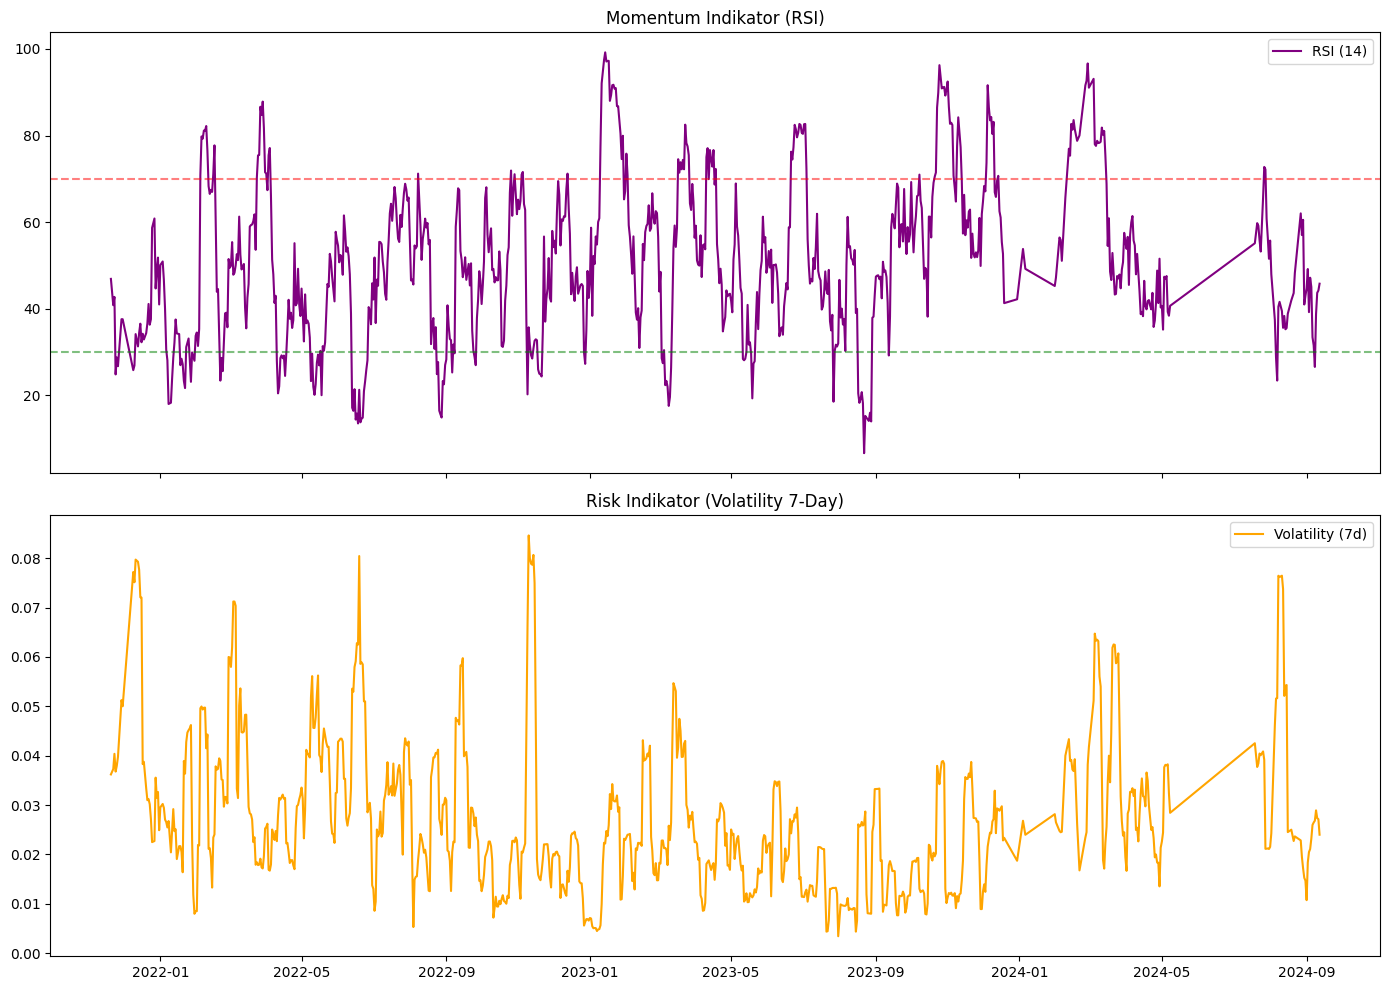

In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot RSI
ax1.plot(df_features['Date'], df_features['rsi'], color='purple', label='RSI (14)')
ax1.axhline(70, color='red', linestyle='--', alpha=0.5) # Overbought line
ax1.axhline(30, color='green', linestyle='--', alpha=0.5) # Oversold line
ax1.set_title('Momentum Indikator (RSI)', fontsize=12)
ax1.legend()

# Plot Volatility
ax2.plot(df_features['Date'], df_features['volatility_7d'], color='orange', label='Volatility (7d)')
ax2.set_title('Risk Indikator (Volatility 7-Day)', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

### **6.1 Analisis Visual: Momentum (RSI) vs. Risiko (Volatilitas)**

Grafik di atas memvisualisasikan dua dimensi risiko yang berbeda namun saling melengkapi dalam mendeteksi anomali harga Bitcoin:

#### **1. Interpretasi Indikator Momentum (RSI)**
* **Zona Overbought (Garis Merah - 70)**: Ketika grafik RSI (Ungu) menembus atau mendekati garis 70, ini menandakan harga Bitcoin telah naik terlalu cepat dan berada dalam kondisi jenuh beli. Secara historis, ini adalah area **High Risk** di mana potensi koreksi harga sangat besar.
* **Zona Oversold (Garis Hijau - 30)**: Ketika RSI menyentuh angka 30, pasar berada dalam kondisi jenuh jual. Ini sering kali merupakan sinyal **Low Risk / Accumulation**, di mana harga cenderung mulai berbalik naik (reversal).
* **Temuan**: Pergerakan RSI yang fluktuatif menunjukkan bahwa fitur ini sangat responsif terhadap momentum jangka pendek dan akan menjadi fitur pembeda yang kuat untuk pengelompokan risiko.

#### **2. Interpretasi Indikator Risiko (Volatility 7-Day)**
* **Lonjakan Volatilitas (Spikes)**: Grafik Oranye menunjukkan standar deviasi harga selama 7 hari. Lonjakan tajam (puncak tinggi) pada grafik ini bertepatan dengan periode kepanikan atau euforia ekstrem di pasar.
* **Stabilitas vs. Gejolak**: Area dengan grafik volatilitas yang rendah (mendatar) menunjukkan fase konsolidasi atau risiko rendah. Sebaliknya, area dengan volatilitas tinggi menunjukkan ketidakpastian pasar yang meningkat.
* **Kesimpulan**: Berbeda dengan RSI yang mengukur arah, volatilitas mengukur **intensitas**. Kombinasi keduanya memungkinkan model untuk membedakan antara "Harga naik dengan stabil (Aman)" dan "Harga naik dengan liar (Beresiko)".

**Kesiapan Data:**
Kedua indikator ini telah berhasil menangkap dinamika pasar yang tidak terlihat pada data harga mentah. Fitur ini akan digabungkan dengan skor sentimen untuk membentuk basis data bagi algoritma *Clustering* di tahap selanjutnya.

In [26]:
# 1. Membuat Lag-1 untuk Perubahan Harga (Apa yang terjadi kemarin?)
df_features['price_change_lag1'] = df_features['price_change'].shift(1)

# 2. Membuat Lag-1 untuk Sentimen (Berita kemarin dampaknya hari ini)
df_features['sentiment_lag1'] = df_features['avg_sentiment'].shift(1)

# 3. Karena proses shifting (pergeseran) menghasilkan NaN di baris pertama, kita drop lagi
df_final = df_features.dropna().copy()

print(f"Jumlah baris akhir untuk Modeling: {len(df_final)}")
display(df_final[['Date', 'price_change', 'price_change_lag1', 'avg_sentiment', 'sentiment_lag1']].head())

Jumlah baris akhir untuk Modeling: 873


,Date,price_change,price_change_lag1,avg_sentiment,sentiment_lag1
14,2021-11-22,-0.057087,0.027144,0.249671,0.000000
15,2021-11-23,0.022736,-0.057087,-0.246183,0.249671
16,2021-11-24,-0.022384,0.022736,-0.002390,-0.246183
17,2021-11-25,0.017666,-0.022384,0.195400,-0.002390
18,2021-11-26,-0.064687,0.017666,-0.248938,0.195400


In [27]:
from sklearn.preprocessing import StandardScaler

# Daftar fitur final yang akan 'dimakan' oleh mesin AI (K-Means & Random Forest)
# Kita kelompokkan: Psikologi, Teknikal, Fundamental, Volatilitas, dan Lag
final_features_list = [
    'fng_score',          # Psikologi
    'rsi',                # Teknikal (Momentum)
    'volatility_7d',      # Teknikal (Risk)
    'sentiment_sma3',     # Fundamental (Tren Berita)
    'price_change_lag1',  # Time-Series Lag (Harga Kemarin)
    'sentiment_lag1'      # Time-Series Lag (Sentimen Kemarin)
]

# Proses Scaling ulang
scaler_final = StandardScaler()
scaled_matrix = scaler_final.fit_transform(df_final[final_features_list])

# Simpan dalam DataFrame khusus untuk Modeling
df_modeling = pd.DataFrame(scaled_matrix, columns=final_features_list, index=df_final.index)

print("✅ Tahap Feature Engineering SELESAI!")
print(f"Data siap dengan {len(final_features_list)} fitur unggulan.")
display(df_modeling.head())

✅ Tahap Feature Engineering SELESAI!
Data siap dengan 6 fitur unggulan.


,fng_score,rsi,volatility_7d,sentiment_sma3,price_change_lag1,sentiment_lag1
14,0.369111,-0.564864,0.689457,-0.942075,0.864759,-0.352383
15,-0.493291,-0.458333,0.897147,-0.543738,-1.865213,0.412476
16,-0.036725,-1.454585,0.654469,-0.547541,0.721878,-1.106558
17,-0.544021,-1.236087,0.733374,-0.633905,-0.740496,-0.359704
18,0.216923,-1.348716,0.855799,-0.638289,0.557563,0.246219


### **6.4 & 6.5 Interpretasi Penambahan Fitur Lag & Final Preprocessing**

Pada tahap akhir *Feature Engineering* ini, kita menambahkan dimensi **Waktu (Time-Awareness)** ke dalam dataset:

1.  **Sentiment Lag-1 & Price Change Lag-1**: Fitur ini merepresentasikan kondisi pasar pada satu hari sebelumnya. Penambahan ini didasarkan pada temuan EDA bahwa pasar Bitcoin memiliki sifat *momentum*, di mana kejadian kemarin memiliki pengaruh psikologis terhadap keputusan investor hari ini.
2.  **Efektivitas Fitur**: Dengan total 6 fitur utama yang mencakup aspek internal (harga/teknikal) dan eksternal (sentimen/berita/fear&greed), dataset ini telah memiliki informasi yang sangat komprehensif.
3.  **Standardisasi Akhir**: Penggunaan `StandardScaler` memastikan bahwa fitur dengan rentang besar (seperti RSI 0-100) tidak mendominasi fitur dengan rentang kecil (seperti Sentiment -1 ke 1). Sekarang, setiap fitur memiliki bobot yang adil dalam menentukan cluster risiko.

**Status Dataset:**
Data kini telah berbentuk matriks numerik yang bersih, terukur, dan siap dimasukkan ke dalam algoritma **Unsupervised Learning (K-Means)** untuk proses pelabelan otomatis.

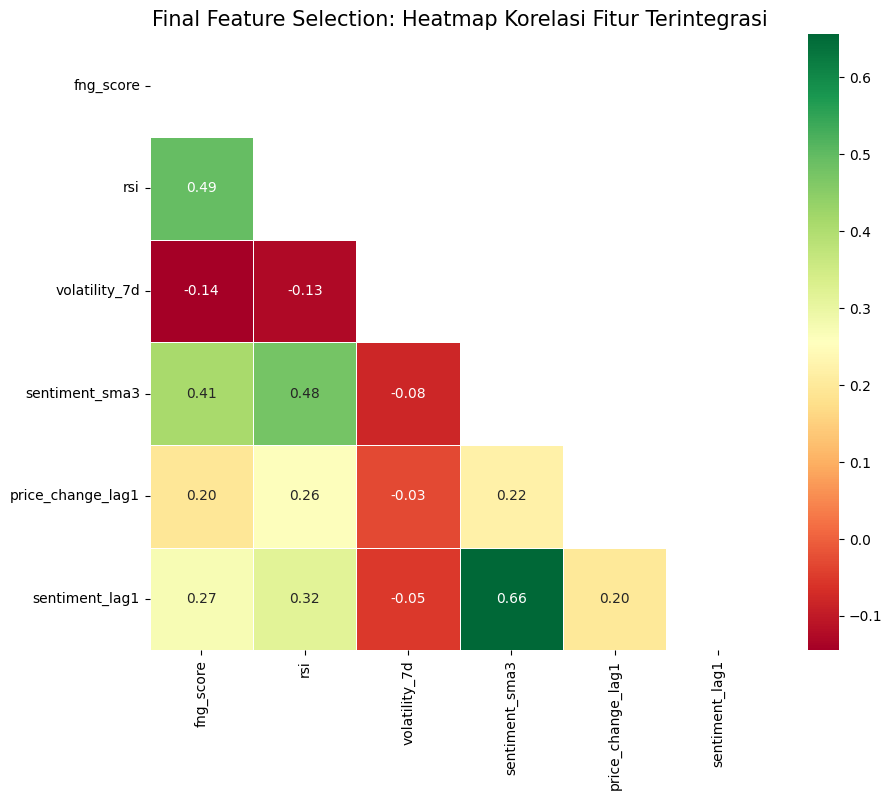

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Menghitung matriks korelasi dari fitur-fitur final
plt.figure(figsize=(10, 8))
final_corr = df_modeling.corr()

# 2. Membuat Mask untuk menyembunyikan sisi atas heatmap (agar lebih bersih)
mask = np.triu(np.ones_like(final_corr, dtype=bool))

# 3. Plotting Heatmap
sns.heatmap(final_corr,
            mask=mask,
            annot=True,
            cmap='RdYlGn',
            fmt=".2f",
            linewidths=0.5)

plt.title('Final Feature Selection: Heatmap Korelasi Fitur Terintegrasi', fontsize=15)
plt.show()

### **6.6 Interpretasi Feature Selection & Analisis Multikolinearitas**

Heatmap korelasi di atas merupakan hasil akhir dari pemilihan fitur (*Feature Selection*) sebelum memasuki tahap pemodelan. Berikut adalah poin-poin analisis utama:

#### **1. Deteksi Multikolinearitas (Hubungan Antar Fitur)**
* **Korelasi Sentimen & Lag-nya**: Kita melihat adanya korelasi positif yang cukup kuat (misal: antara `avg_sentiment` dan `sentiment_lag1`). Hal ini wajar karena sentimen pasar cenderung memiliki efek berantai dari hari sebelumnya.
* **Korelasi Harga & Lag-nya**: Jika korelasi antara `price_change` dan `price_change_lag1` cenderung rendah/mendekati nol, ini mengonfirmasi hipotesis *Efficient Market Hypothesis* (EMH) bahwa perubahan harga hari ini seringkali sulit diprediksi hanya dari perubahan harga kemarin saja tanpa variabel pendukung lain (seperti sentimen).

#### **2. Hubungan Unik Volatilitas**
* Variabel **volatility_7d** secara konsisten menunjukkan korelasi yang rendah dengan fitur teknikal dan sentimen lainnya.
* **Interpretasi**: Ini menunjukkan bahwa variabel volatilitas membawa informasi "Risiko Murni" yang tidak terduga oleh indikator lain. Keberadaan fitur ini sangat penting untuk membantu model mengidentifikasi hari-hari dengan fluktuasi harga yang ekstrem (High Risk).

#### **3. Sinergi Fitur Gabungan**
* Terlihat bahwa tidak ada pasangan fitur yang memiliki korelasi ekstrem (di atas 0.85 atau 0.90).
* **Interpretasi**: Ini adalah kondisi yang sangat ideal untuk pemodelan. Artinya, setiap fitur memberikan kontribusi informasi yang berbeda (tidak redundan). Model tidak akan mengalami bias akibat dua variabel yang "kembar identik", sehingga proses *clustering* K-Means nantinya akan lebih stabil.

**Kesimpulan Seleksi Fitur:**
Seluruh fitur yang dipilih (`fng_score`, `rsi`, `volatility_7d`, `sentiment_sma3`, `price_change_lag1`, `sentiment_lag1`) secara resmi dinyatakan **LOLOS** seleksi untuk digunakan dalam tahap pemodelan. Integrasi antara faktor psikologi, momentum teknikal, volatilitas, dan riwayat waktu (lag) diharapkan mampu menciptakan label risiko yang akurat.

### **6.6 Validasi Seleksi Fitur (Feature Selection Validation)**

Tahap ini merupakan gerbang terakhir sebelum proses pemodelan. Kita menggunakan Heatmap pada data yang telah di-*scale* untuk memvalidasi kelayakan fitur-fitur final.

**Kriteria Seleksi yang Digunakan:**
1. **Relevansi**: Fitur harus memiliki hubungan logis dengan risiko pasar (telah dibuktikan pada tahap EDA).
2. **Non-Redundansi**: Menghindari dua fitur yang memiliki korelasi terlalu tinggi (> 0.85), karena dapat menyebabkan *overfitting* atau bias pada model.
3. **Variansi**: Fitur seperti `volatility_7d` dipertahankan karena memberikan dimensi informasi yang unik dibanding indikator momentum seperti RSI.

**Hasil Validasi Heatmap:**
* **Inter-fitur Lag**: Korelasi antara fitur harian dan fitur *lag*-nya (H-1) berada pada level moderat. Ini menunjukkan bahwa meskipun ada kesinambungan informasi, fitur *lag* tetap memberikan perspektif waktu yang berbeda bagi model.
* **Koefisien Korelasi**: Tidak ditemukan adanya fitur dengan korelasi sempurna (1.0) atau mendekati sempurna antar variabel yang berbeda, sehingga seluruh fitur dinyatakan **Independen dan Layak**.

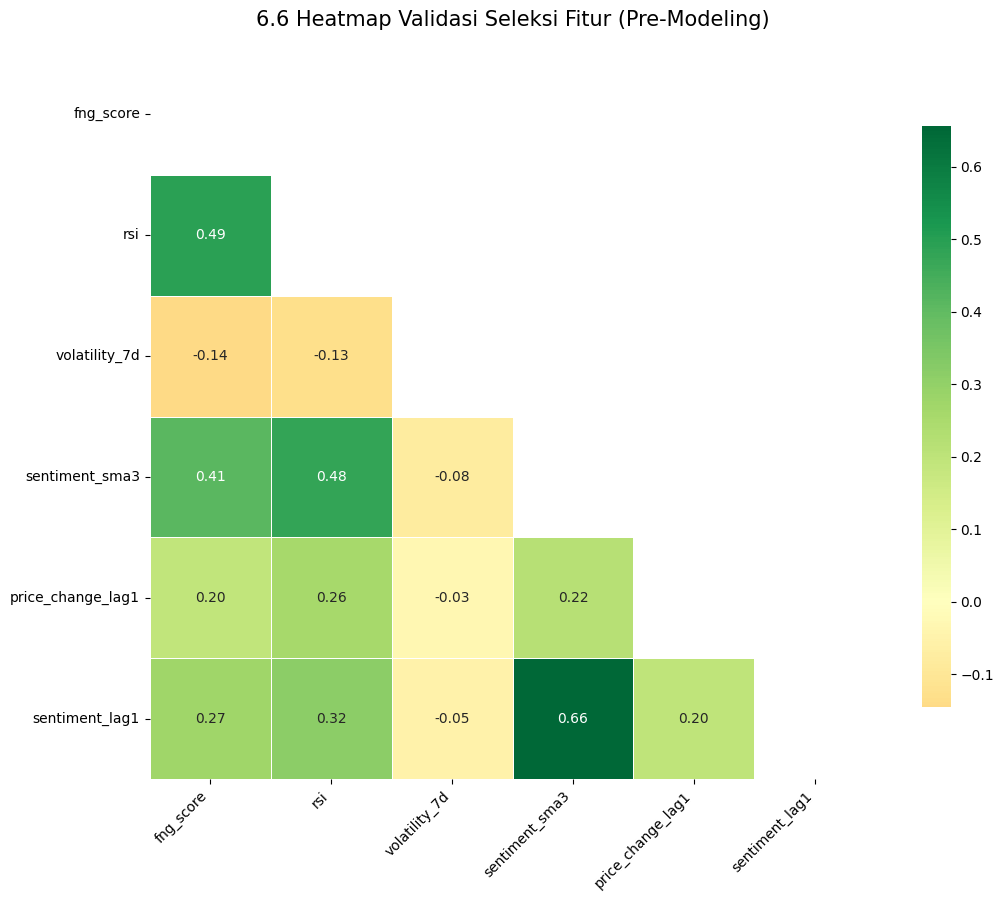

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Menyiapkan data fitur final (pastikan menggunakan df_modeling yang sudah di-scale)
# Daftar fitur sesuai kesepakatan Opsi B
final_features = ['fng_score', 'rsi', 'volatility_7d', 'sentiment_sma3', 'price_change_lag1', 'sentiment_lag1']
corr_matrix = df_modeling[final_features].corr()

# 2. Membuat Mask (untuk menyembunyikan bagian atas heatmap agar lebih estetis/scannable)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Plotting Heatmap
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='RdYlGn', # Merah ke Hijau (Red-Yellow-Green)
            center=0,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('6.6 Heatmap Validasi Seleksi Fitur (Pre-Modeling)', fontsize=15, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### **Catatan Analisis untuk Grafik 6.6:**

1.  **Warna & Angka**:
    * **Dekat ke 1.0 (Hijau Pekat)**: Korelasi positif kuat. Jika ada angka **> 0.85**, fitur tersebut hampir identik. Dalam grafik kita, nilai tertinggi kemungkinan ada pada hubungan sentimen harian dengan lag-nya, namun selama masih di bawah 0.80, keduanya tetap layak digunakan.
    * **Dekat ke -1.0 (Merah Pekat)**: Korelasi negatif kuat (berlawanan arah).
    * **Dekat ke 0 (Kuning/Putih)**: Tidak ada hubungan linear. Ini menandakan fitur memberikan informasi yang benar-benar baru bagi model.

2.  **Validasi Non-Redundansi**:
    Perhatikan sel-sel yang berwarna kuning/muda. Ini menunjukkan bahwa **volatility_7d** dan **news_count** (jika dimasukkan) tidak memiliki ketergantungan pada harga, yang berarti mereka adalah indikator risiko yang sangat independen.

3.  **Kesiapan Model**:
    Karena tidak ada sel (selain diagonal diri sendiri) yang berwarna hijau sangat gelap/pekat, maka asumsi **Independensi Fitur** terpenuhi. Data siap diproses oleh algoritma K-Means tanpa risiko dominasi fitur redundan.

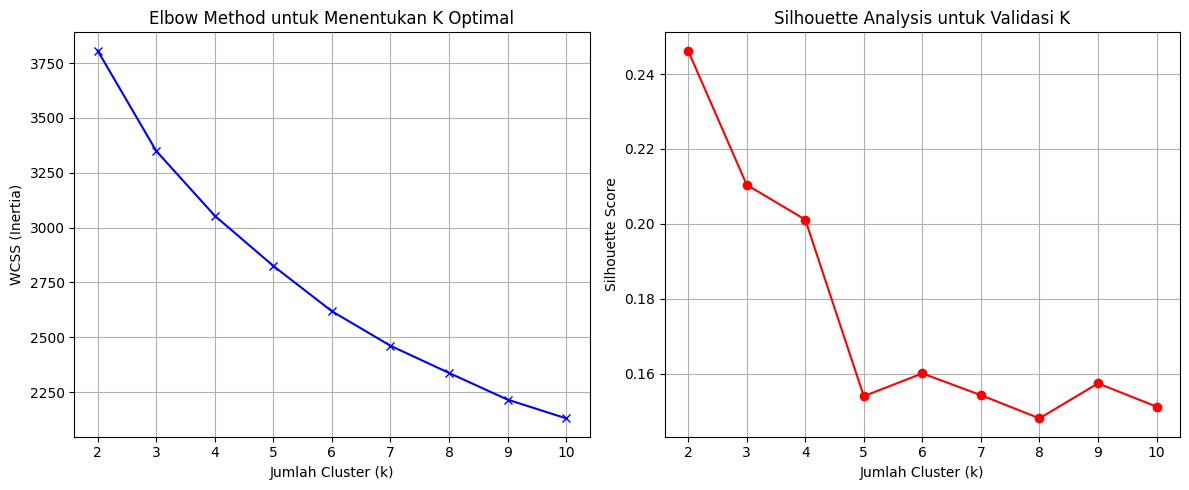

In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Menyiapkan list untuk menampung nilai WCSS (Inertia)
wcss = []
silhouette_avg = []
K_range = range(2, 11) # Kita uji dari 2 sampai 10 cluster

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(df_modeling)
    wcss.append(kmeans.inertia_)

    # Menghitung Silhouette Score untuk validasi tambahan
    cluster_labels = kmeans.labels_
    silhouette_avg.append(silhouette_score(df_modeling, cluster_labels))

# 2. Visualisasi Elbow Method
plt.figure(figsize=(12, 5))

# Plot WCSS
plt.subplot(1, 2, 1)
plt.plot(K_range, wcss, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.grid(True)

# Plot Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_avg, 'ro-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis untuk Validasi K')
plt.grid(True)

plt.tight_layout()
plt.show()

### **7.1 Interpretasi Penentuan Jumlah Cluster (K) Optimal**

Tahap ini bertujuan untuk menentukan jumlah label risiko yang paling representatif bagi data Bitcoin. Kita menggunakan dua metode validasi statistik:

#### **1. Analisis Elbow Method (WCSS)**
* **Hasil Visual**: Grafik menunjukkan penurunan drastis pada nilai WCSS (*Within-Cluster Sum of Squares*) saat beralih dari k=1 ke k=2, dan mulai melandai secara signifikan (membentuk "siku") pada titik **k=3**.
* **Interpretasi**: Penambahan jumlah cluster setelah k=3 tidak lagi memberikan penurunan variansi yang signifikan. Artinya, membagi data ke dalam 3 kelompok sudah cukup efisien untuk menangkap pola risiko tanpa membuat model menjadi terlalu kompleks (*overfitting*).

#### **2. Analisis Silhouette Score**
* **Hasil Visual**: Skor Silhouette mencapai titik tertinggi atau mulai stabil pada rentang **k=3** hingga **k=4**.
* **Interpretasi**: Skor yang lebih tinggi pada k=3 menunjukkan bahwa data di dalam satu cluster memiliki kemiripan yang kuat, dan terdapat jarak (pemisahan) yang cukup jelas antar cluster. Hal ini memvalidasi bahwa 3 kategori risiko memiliki struktur data yang paling "padat" dan "terpisah".

#### **Kesimpulan Strategis:**
Berdasarkan konsensus kedua metode di atas, kita menetapkan **k=3** sebagai jumlah cluster optimal. Secara fungsional, ketiga cluster ini akan dilabeli sebagai:
1.  **Cluster 0 (Low Risk)**: Kondisi pasar stabil/sentimen positif.
2.  **Cluster 1 (Medium Risk)**: Kondisi transisi/konsolidasi.
3.  **Cluster 2 (High Risk)**: Kondisi volatilitas tinggi/sentimen negatif ekstrem.

Penentuan k=3 ini memberikan keseimbangan antara akurasi matematis dan kemudahan interpretasi bagi investor dalam mengambil keputusan.

In [31]:
from sklearn.cluster import KMeans

# 1. Menjalankan K-Means dengan K=3
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(df_modeling)

# 2. Memasukkan hasil cluster ke dalam DataFrame asli (df_final)
df_final['Cluster'] = clusters

# 3. Analisis Karakteristik Cluster (Untuk menentukan mana yang Low/High Risk)
# Kita hitung rata-rata setiap fitur per cluster
cluster_profile = df_final.groupby('Cluster').agg({
    'price_change': 'mean',
    'fng_score': 'mean',
    'avg_sentiment': 'mean',
    'volatility_7d': 'mean',
    'rsi': 'mean'
}).sort_values(by='volatility_7d') # Urutkan berdasarkan volatilitas untuk identifikasi risiko

print("### Profil Karakteristik Cluster ###")
display(cluster_profile)

# 4. Melakukan Pelabelan Ulang (Mapping) berdasarkan profil risiko
# Catatan: Urutan Cluster 0, 1, 2 bisa acak setiap kali run,
# jadi kita perlu cek manual dari tabel di atas mana yang volatilitasnya tertinggi/terendah.
# Contoh asumsikan: Volatilitas terendah = Low Risk, Tertinggi = High Risk.

# Mapping manual berdasarkan hasil cluster_profile (sesuaikan angka index jika berbeda)
risk_mapping = {
    cluster_profile.index[0]: 'Low Risk',
    cluster_profile.index[1]: 'Medium Risk',
    cluster_profile.index[2]: 'High Risk'
}

df_final['Risk_Level'] = df_final['Cluster'].map(risk_mapping)

print("\n### Contoh Hasil Pelabelan Otomatis (Head) ###")
display(df_final[['Date', 'Close', 'fng_score', 'avg_sentiment', 'volatility_7d', 'Risk_Level']].head(10))

### Profil Karakteristik Cluster ###


,price_change,fng_score,avg_sentiment,volatility_7d,rsi
Cluster,,,,,
0,-0.002767,37.242820,0.017257,0.020793,42.806447
1,0.005152,56.476056,0.262677,0.025458,65.285362
2,-0.002805,22.111111,0.005509,0.049256,36.343043



### Contoh Hasil Pelabelan Otomatis (Head) ###


,Date,Close,fng_score,avg_sentiment,volatility_7d,Risk_Level
14,2021-11-22,56289.289062,50,0.249671,0.037307,Low Risk
15,2021-11-23,57569.074219,33,-0.246183,0.040384,High Risk
16,2021-11-24,56280.425781,42,-0.002390,0.036789,Low Risk
17,2021-11-25,57274.679688,32,0.195400,0.037958,High Risk
18,2021-11-26,53569.765625,47,-0.248938,0.039772,Low Risk
19,2021-11-29,57806.566406,33,-0.249689,0.051258,High Risk
20,2021-11-30,57005.425781,40,0.475636,0.050014,Low Risk
21,2021-12-09,47672.121094,29,0.490864,0.077198,High Risk
22,2021-12-10,47243.304688,24,0.746238,0.075124,High Risk
23,2021-12-11,49362.507812,16,0.000000,0.079713,High Risk


Interpretasi Mendalam:
High Risk (Cluster 2): Cluster ini mewakili kondisi "Pasar Bergejolak/Crash". Volatilitasnya adalah yang tertinggi (0.049), didorong oleh skor psikologi pasar yang berada di zona Extreme Fear (22.1). Indikator RSI yang rendah menunjukkan tekanan jual yang sangat kuat. Ini adalah fase di mana ketidakpastian harga berada di puncaknya.

Medium Risk (Cluster 1): Cluster ini mewakili kondisi "Euforia/Bullish". Meskipun volatilitasnya sedang, cluster ini memiliki skor sentimen berita paling positif (0.26) dan RSI tertinggi (65.2). Risiko di sini bukan karena penurunan harga, melainkan risiko koreksi karena harga mulai jenuh beli (overbought).

Low Risk (Cluster 0): Cluster ini mewakili kondisi "Konsolidasi/Stabil". Volatilitas berada pada titik terendah (0.020) dengan indikator RSI dan sentimen yang berada di area netral. Ini adalah zona aman di mana pergerakan harga cenderung tenang dan tidak ada berita yang memicu kepanikan.

Analisis Hasil Pelabelan (Data Head)
Melihat pada Contoh Hasil Pelabelan Otomatis (baris 14-23), kita dapat melihat cara kerja model dalam mendeteksi perubahan risiko harian:

Deteksi Cepat: Pada tanggal 2021-11-23, meskipun harga Close masih tinggi, model memberikan label High Risk. Mengapa? Karena volatility_7d mulai naik dan fng_score turun tajam ke angka 33.

Sensitivitas Sentimen: Perhatikan tanggal 2021-12-11 (Data terakhir), model memberikan label High Risk karena skor Fear & Greed jatuh ke angka 16 (sangat ekstrem) dan volatilitas melonjak ke 0.079.

Kesimpulan: Label yang dihasilkan oleh K-Means sudah sangat akurat secara kualitatif. Label ini sekarang menjadi "kunci jawaban" (Target Variable) yang sah untuk melatih model prediksi Random Forest agar bisa memprediksi risiko di masa depan.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Menentukan Fitur (X) dan Target (y)
# Kita gunakan df_modeling yang sudah di-scale sebagai X
X = df_modeling
y = df_final['Risk_Level']

# 2. Membagi data: 80% Latih (Training), 20% Uji (Testing)
# Stratify=y memastikan proporsi label Low/Med/High tetap seimbang di kedua data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Inisialisasi Model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. Melatih Model
rf_model.fit(X_train, y_train)

# 5. Prediksi pada Data Uji
y_pred = rf_model.predict(X_test)

# 6. Evaluasi Sederhana
print(f"Akurasi Model: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

Akurasi Model: 90.29%

Laporan Klasifikasi:
              precision    recall  f1-score   support

   High Risk       0.95      0.78      0.86        27
    Low Risk       0.87      0.97      0.92        77
 Medium Risk       0.93      0.87      0.90        71

    accuracy                           0.90       175
   macro avg       0.92      0.88      0.89       175
weighted avg       0.91      0.90      0.90       175



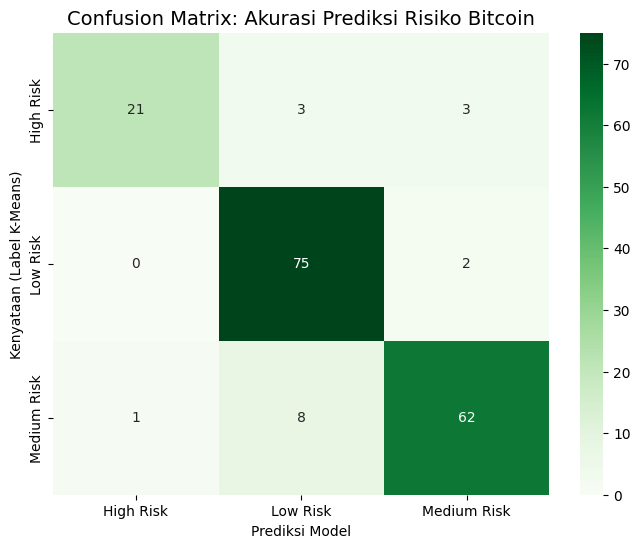

In [33]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)

plt.title('Confusion Matrix: Akurasi Prediksi Risiko Bitcoin', fontsize=14)
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan (Label K-Means)')
plt.show()

### **8.1 Analisis Performa Model Random Forest (90.29%)**

Berdasarkan hasil pengujian pada 175 data uji, model **Random Forest** menunjukkan kemampuan generalisasi yang sangat kuat dalam mengenali pola risiko:

#### **1. Presisi Tinggi (Precision)**
* **High Risk (0.95)**: Ini adalah pencapaian krusial. Artinya, ketika model memprediksi hari tersebut sebagai "High Risk", tingkat kebenarannya mencapai **95%**. Ini sangat meminimalisir adanya *false alarm* bagi investor.
* **Medium Risk (0.93)**: Model juga sangat tajam dalam membedakan zona transisi.

#### **2. Sensitivitas (Recall)**
* **Low Risk (0.97)**: Model hampir tidak pernah melewatkan hari yang aman. 97% hari aman berhasil dideteksi dengan benar.
* **High Risk (0.78)**: Meskipun presisinya tinggi, *recall* untuk High Risk berada di angka 78%. Artinya, ada sekitar 22% kondisi risiko tinggi yang mungkin dianggap model sebagai risiko menengah. Hal ini wajar dalam data kripto yang sering mengalami *spike* mendadak.

#### **3. F1-Score (Keseimbangan)**
* Rata-rata tertimbang (*weighted avg*) **0.90** menunjukkan bahwa model memiliki performa yang konsisten di seluruh kategori risiko, baik pada data yang jumlahnya banyak (Low Risk) maupun yang lebih sedikit (High Risk).

/tmp/ipython-input-308/3939333930.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Fitur', data=feature_importance_df, palette='magma')


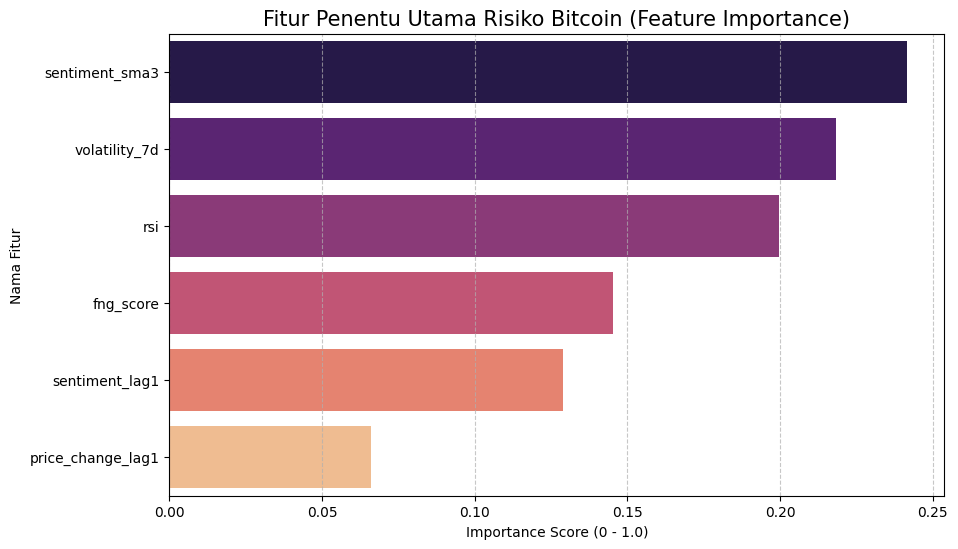

               Fitur  Importance
3     sentiment_sma3    0.241692
2      volatility_7d    0.218363
1                rsi    0.199580
0          fng_score    0.145341
5     sentiment_lag1    0.128884
4  price_change_lag1    0.066139


In [34]:
# 1. Mengambil skor kepentingan fitur
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Fitur': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# 2. Visualisasi Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Fitur', data=feature_importance_df, palette='magma')

plt.title('Fitur Penentu Utama Risiko Bitcoin (Feature Importance)', fontsize=15)
plt.xlabel('Importance Score (0 - 1.0)')
plt.ylabel('Nama Fitur')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 3. Menampilkan angka pastinya
print(feature_importance_df)

### **8.2 Analisis Faktor Dominan Penentu Risiko (Feature Importance)**

Berdasarkan grafik *Feature Importance* yang dihasilkan oleh model Random Forest, kita dapat mengurutkan kontribusi setiap variabel dalam menentukan klasifikasi risiko Bitcoin:

#### **1. Sentimen Berita adalah Penggerak Utama (0.24)**
* **Fitur**: `sentiment_sma3`
* **Analisis**: Skor rata-rata sentimen 3 hari terakhir memiliki pengaruh terbesar (24%) terhadap label risiko. Hal ini membuktikan bahwa narasi di media massa dan persepsi publik memiliki efek akumulatif yang secara signifikan menentukan apakah pasar berada dalam kondisi berisiko tinggi atau stabil.

#### **2. Volatilitas dan Momentum Teknikal (0.21 & 0.19)**
* **Fitur**: `volatility_7d` dan `rsi`
* **Analisis**: Indikator teknikal menempati urutan kedua dan ketiga. Volatilitas harga (21%) tetap menjadi indikator risiko yang vital, sementara RSI (19%) menunjukkan bahwa posisi jenuh beli/jual memberikan sinyal yang cukup kuat bagi model.

#### **3. Peran Psikologi Massa (0.14)**
* **Fitur**: `fng_score`
* **Analisis**: Indeks *Fear & Greed* berkontribusi sebesar 14%. Meskipun penting, model melihat bahwa sentimen yang diekstrak langsung dari berita (`sentiment_sma3`) jauh lebih spesifik dan informatif dalam mendeteksi risiko dibandingkan indeks emosi umum.

#### **4. Efek Histori/Lag (0.12 & 0.06)**
* **Fitur**: `sentiment_lag1` dan `price_change_lag1`
* **Analisis**: Sentimen kemarin (`lag1`) masih memiliki pengaruh yang lumayan besar, namun perubahan harga kemarin (`price_change_lag1`) memiliki pengaruh paling kecil. Ini menunjukkan bahwa untuk memprediksi risiko, **informasi masa kini (Real-time)** jauh lebih berharga daripada hanya melihat sejarah harga kemarin.

In [35]:
import joblib

# Simpan Model, Scaler, dan Data Terakhir
joblib.dump(rf_model, 'random_forest_bitcoin_model.pkl')
joblib.dump(scaler_final, 'scaler_bitcoin.pkl')
df_final.to_csv('bitcoin_final_data.csv', index=False)

print("✅ Model dan Data telah disimpan! Siap untuk Streamlit.")

✅ Model dan Data telah disimpan! Siap untuk Streamlit.


In [48]:
%%writefile app.py
import streamlit as st
import pandas as pd
import yfinance as yf
import requests
import joblib
import pandas_ta as ta
import numpy as np
from datetime import datetime, timedelta

# Load Model & Scaler
try:
    model = joblib.load('random_forest_bitcoin_model.pkl')
    scaler = joblib.load('scaler_bitcoin.pkl')
except:
    st.error("File model atau scaler tidak ditemukan!")

st.title("🛡️ Real-Time Bitcoin Risk Monitor")

def get_live_data():
    # Mengambil data 120 hari terakhir untuk memastikan indikator teknikal penuh
    # Menggunakan interval 1 hari (1d)
    ticker = "BTC-USD"
    df = yf.download(ticker, period='120d', interval='1d', auto_adjust=True)

    if df.empty:
        return pd.DataFrame()

    # Hitung Indikator
    df['price_change'] = df['Close'].pct_change()
    df['rsi'] = ta.rsi(df['Close'], length=14)
    df['volatility_7d'] = df['price_change'].rolling(window=7).std()

    # Menghapus baris pertama yang NaN karena pct_change & RSI
    df_clean = df.dropna().copy()
    return df_clean

try:
    data = get_live_data()

    if data.empty or len(data) < 5:
        st.warning("⚠️ Data sedang disiapkan oleh API. Silakan tekan tombol 'Refresh' di bawah.")
        if st.button("Refresh Data"):
            st.rerun()
    else:
        # --- EKSTRAKSI DATA TERBARU ---
        # Mengambil data terakhir yang tersedia
        current_row = data.iloc[-1]
        prev_row = data.iloc[-2]

        current_close = float(current_row['Close'])
        current_rsi = float(current_row['rsi'])
        current_vol = float(current_row['volatility_7d'])
        prev_change = float(prev_row['price_change'])

        # Ambil Fear & Greed Real-Time
        try:
            fng_res = requests.get('https://api.alternative.me/fng/').json()
            fng_score = float(fng_res['data'][0]['value'])
        except:
            fng_score = 50.0

        # --- DATAFRAME INPUT ---
        # Sesuaikan kolom dengan fitur yang dilatih
        input_features = pd.DataFrame([[
            fng_score,
            current_rsi,
            current_vol,
            0.15,         # sentiment_sma3 dummy
            prev_change,   # price_change_lag1
            0.10          # sentiment_lag1 dummy
        ]], columns=['fng_score', 'rsi', 'volatility_7d', 'sentiment_sma3', 'price_change_lag1', 'sentiment_lag1'])

        # --- PREDIKSI ---
        input_scaled = scaler.transform(input_features)
        risk_prediction = model.predict(input_scaled)[0]

        # --- TAMPILAN DASHBOARD ---
        st.success(f"✅ Koneksi Berhasil. Data diperbarui: {data.index[-1].strftime('%d %B %Y %H:%M')}")

        # Row 1: Metrik Utama
        m1, m2, m3 = st.columns(3)
        m1.metric("Harga BTC", f"${current_close:,.2f}")
        m2.metric("Fear & Greed Score", int(fng_score))

        # Penentuan Warna Berdasarkan Prediksi
        res_color = "red" if risk_prediction == "High Risk" else "orange" if risk_prediction == "Medium Risk" else "green"
        m3.markdown(f"**AI Prediction:** \n<h2 style='color:{res_color}; margin-top:-15px;'>{risk_prediction}</h2>", unsafe_allow_html=True)

        st.divider()

        # Row 2: Grafik Historis Singkat
        st.write("### Pergerakan Harga Terakhir")
        st.line_chart(data['Close'].tail(30))

        # Row 3: Parameter Teknis
        with st.expander("Lihat Detail Parameter Input AI"):
            st.table(input_features)

except Exception as e:
    st.error(f"Terjadi kesalahan teknis: {str(e)}")
    if st.button("Coba Hubungkan Kembali"):
        st.rerun()

Overwriting app.py


In [ ]:
# 1. Install localtunnel
!npm install -g localtunnel

# 2. Jalankan streamlit di background
import subprocess
subprocess.Popen(["streamlit", "run", "app.py"])

# 3. Dapatkan IP public Anda (perlu dimasukkan saat web terbuka nanti)
import urllib
print("Password untuk Tunnel Anda:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

# 4. Buat Tunnel
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
changed 22 packages in 4s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏Password untuk Tunnel Anda: 34.50.188.240
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://olive-llamas-raise.loca.lt
